# Brain Tumor Dataset Visualization
This notebook explores and visualizes the brain tumor segmentation dataset.

In [34]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from tqdm import tqdm

# Set matplotlib to display inline
%matplotlib inline

# Set random seed for reproducibility
np.random.seed(42)

## 1. Dataset Overview

In [37]:
# Set data directory
data_dir = 'brain_tumor_dataset/data'

# Get all files
files = os.listdir(data_dir)
mat_files = [f for f in files if f.endswith('.mat')]
indices = [int(f.replace('.mat', '')) for f in mat_files]
indices.sort()

print(f"Total number of samples: {len(indices)}")
print(f"File indices range: {min(indices)} to {max(indices)}")

Total number of samples: 3064
File indices range: 1 to 3064


## 2. Explore Single Sample in Detail

In [40]:
# Load a single sample
sample_idx = indices[0]  # First sample
mat_file = os.path.join(data_dir, f'{sample_idx}.mat')

with h5py.File(mat_file, 'r') as f:
    print("Keys in the file:", list(f.keys()))
    print("Keys in cjdata:", list(f['cjdata'].keys()))
    
    # Load data
    image = np.array(f['cjdata']['image']).astype(np.float32)
    mask = np.array(f['cjdata']['tumorMask']).astype(np.float32)
    label = np.array(f['cjdata']['label'])[0, 0]
    
    # Try to get PID
    try:
        pid = np.array(f['cjdata']['PID'])
        pid_str = ''.join([chr(int(c)) for c in pid.flatten()])
    except:
        pid_str = f'Sample_{sample_idx}'

print(f"\nSample Information:")
print(f"  File Name: {sample_idx}.mat")
print(f"  PID: {pid_str}")
print(f"  Image Shape: {image.shape}")
print(f"  Image Data Type: {image.dtype}")
print(f"  Intensity Range: [{image.min():.2f}, {image.max():.2f}]")
print(f"  Mask Shape: {mask.shape}")
print(f"  Mask Unique Values: {np.unique(mask)}")
print(f"  Label: {int(label)} {'(Tumor Present)' if label > 0 else '(No Tumor)'}")

# Calculate tumor statistics
tumor_pixels = np.sum(mask > 0)
total_pixels = mask.size
tumor_percentage = (tumor_pixels / total_pixels) * 100
print(f"  Tumor Coverage: {tumor_percentage:.2f}% ({tumor_pixels}/{total_pixels} pixels)")

Keys in the file: ['cjdata']
Keys in cjdata: ['PID', 'image', 'label', 'tumorBorder', 'tumorMask']

Sample Information:
  File Name: 1.mat
  PID: 100360
  Image Shape: (512, 512)
  Image Data Type: float32
  Intensity Range: [0.00, 3366.00]
  Mask Shape: (512, 512)
  Mask Unique Values: [0. 1.]
  Label: 1 (Tumor Present)
  Tumor Coverage: 1.74% (4569/262144 pixels)


## 3. Visualize Single Sample

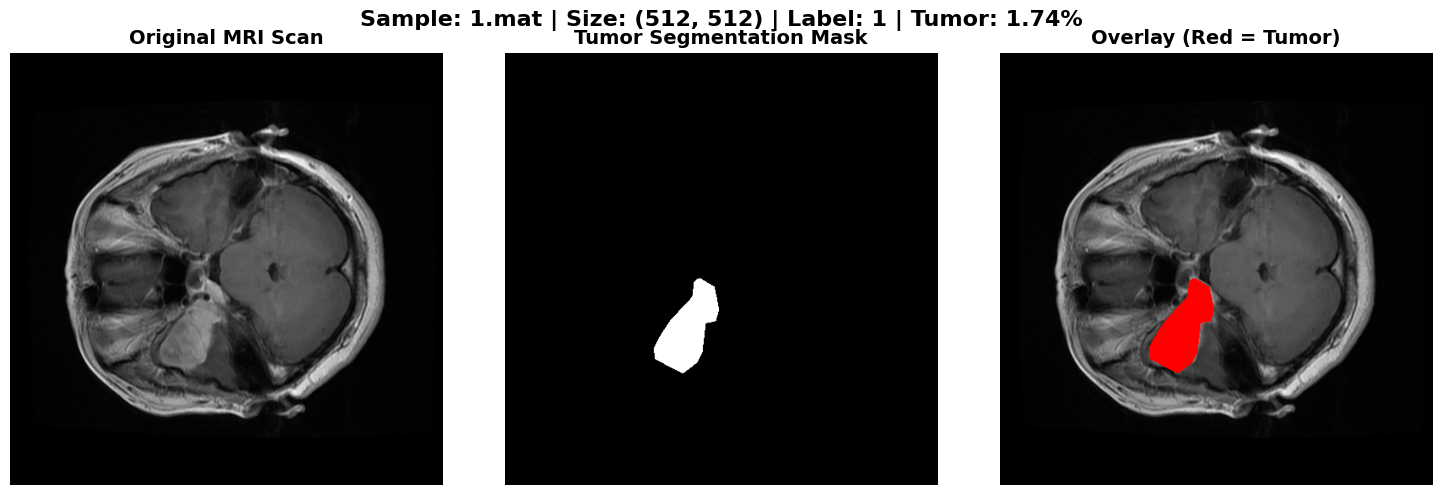

In [43]:
# Normalize image for visualization
image_norm = (image - image.min()) / (image.max() - image.min() + 1e-8)

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
axes[0].imshow(image_norm, cmap='gray')
axes[0].set_title('Original MRI Scan', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Tumor mask
axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Tumor Segmentation Mask', fontsize=14, fontweight='bold')
axes[1].axis('off')

# Overlay
overlay_rgb = np.stack([image_norm, image_norm, image_norm], axis=-1)
overlay_rgb[mask > 0] = [1, 0, 0]  # Red for tumor
axes[2].imshow(overlay_rgb)
axes[2].set_title('Overlay (Red = Tumor)', fontsize=14, fontweight='bold')
axes[2].axis('off')

fig.suptitle(f'Sample: {sample_idx}.mat | Size: {image.shape} | Label: {int(label)} | Tumor: {tumor_percentage:.2f}%',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Browse Multiple Samples

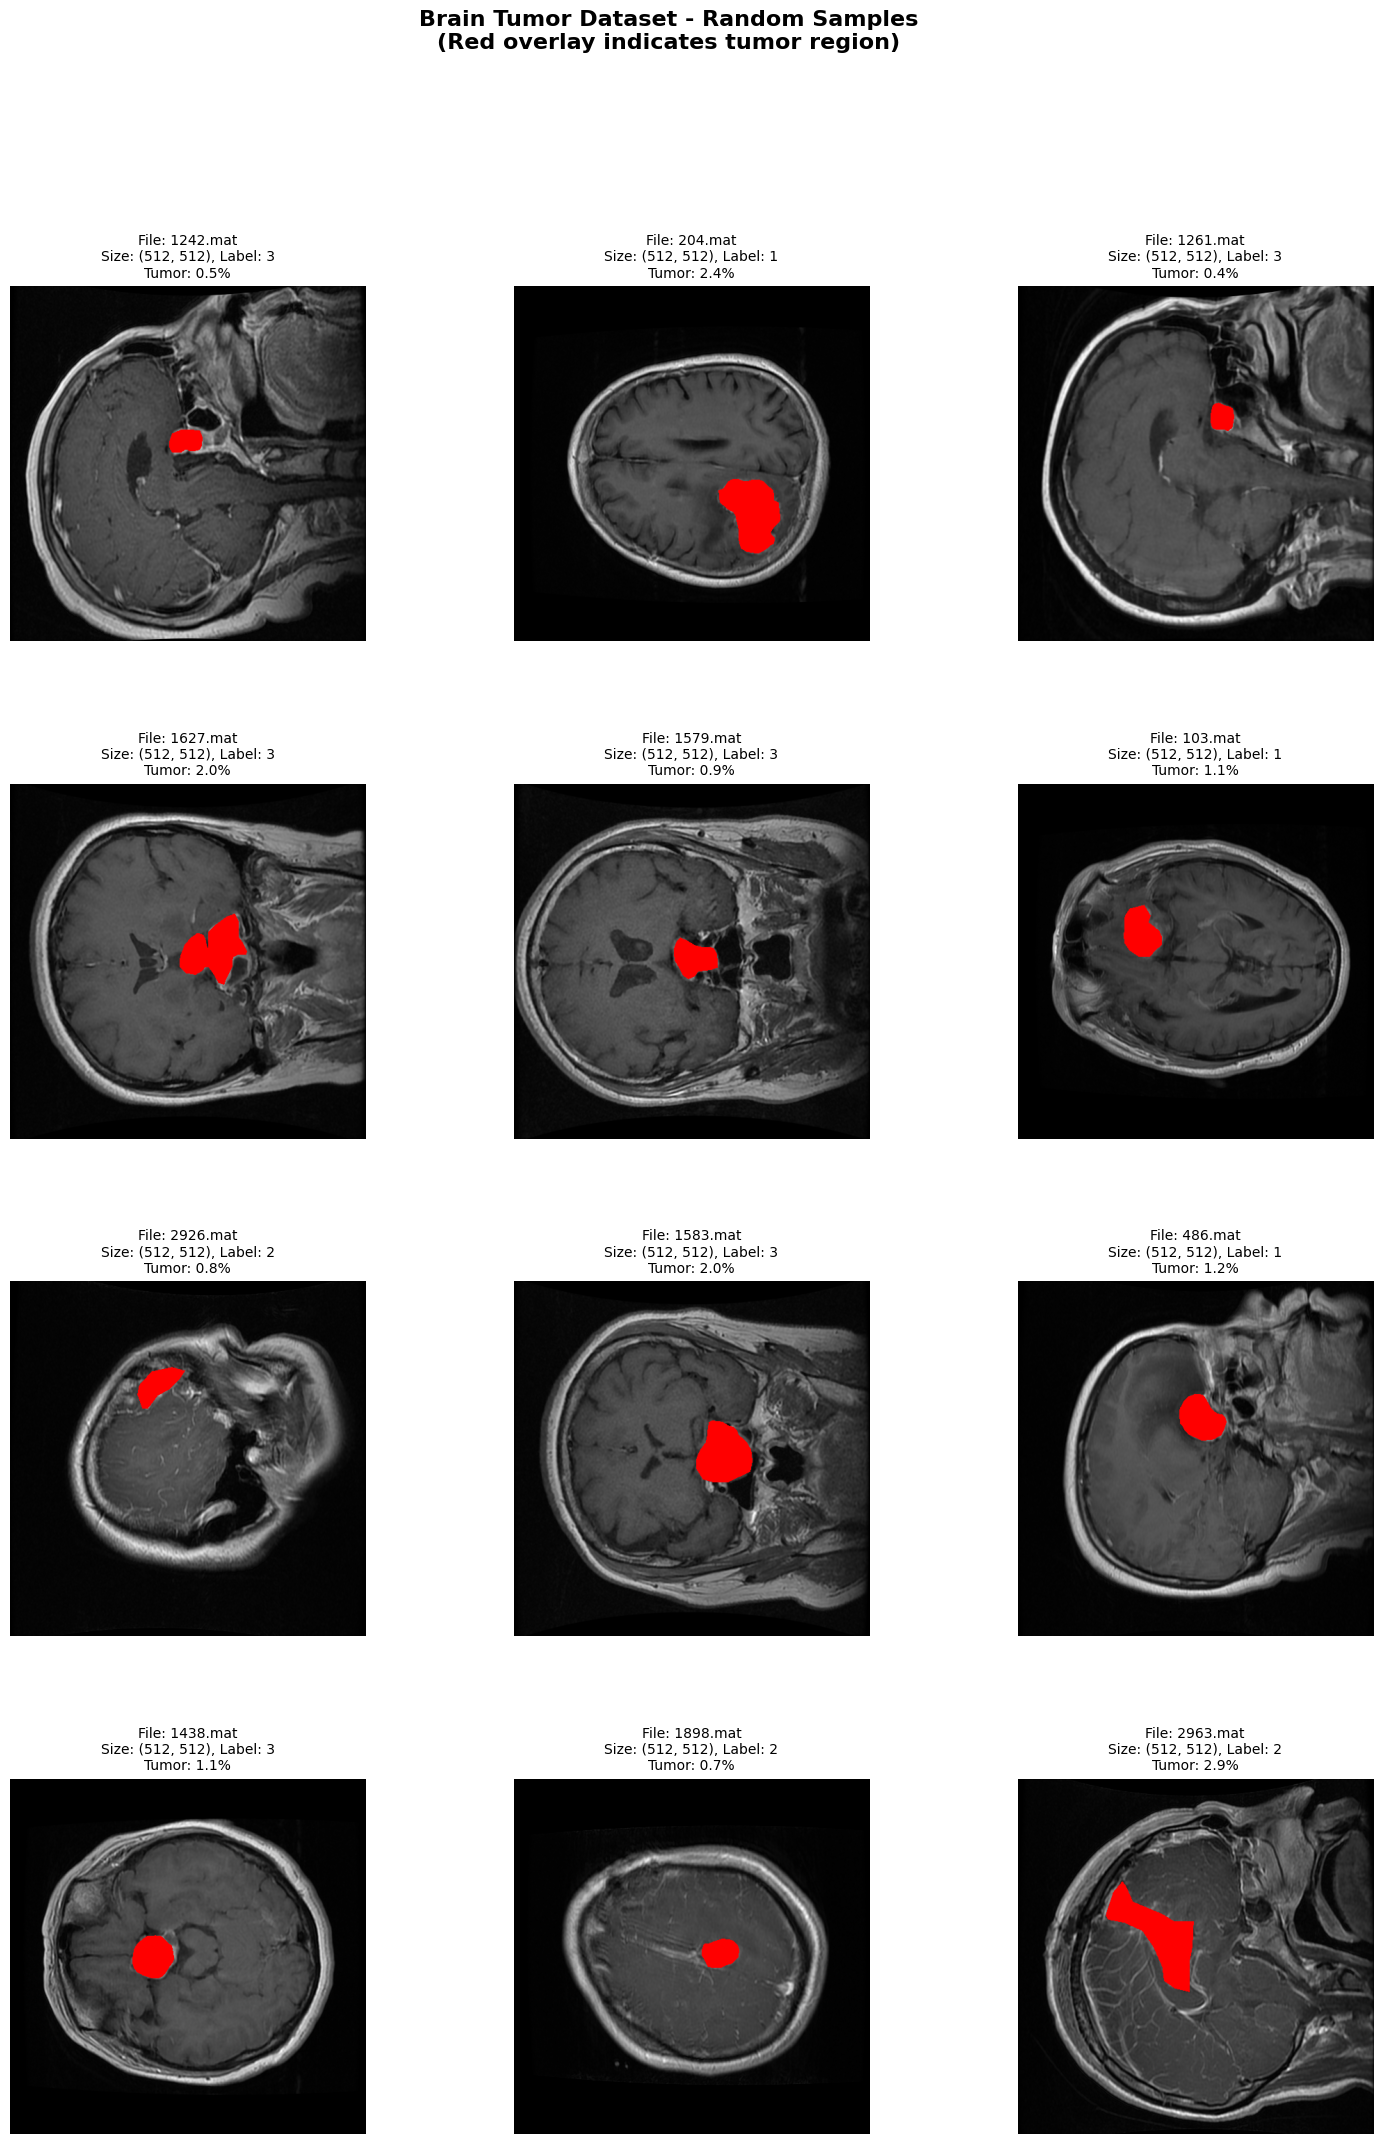

In [46]:
# Visualize multiple random samples
num_samples = 12
selected_indices = np.random.choice(indices, num_samples, replace=False)

rows = (num_samples + 2) // 3
fig = plt.figure(figsize=(18, 6 * rows))
gs = GridSpec(rows, 3, figure=fig, hspace=0.4, wspace=0.3)

for idx, file_idx in enumerate(selected_indices):
    mat_file = os.path.join(data_dir, f'{file_idx}.mat')
    
    # Load data
    with h5py.File(mat_file, 'r') as f:
        image = np.array(f['cjdata']['image']).astype(np.float32)
        mask = np.array(f['cjdata']['tumorMask']).astype(np.float32)
        label = np.array(f['cjdata']['label'])[0, 0]
    
    # Normalize
    image_norm = (image - image.min()) / (image.max() - image.min() + 1e-8)
    
    # Calculate tumor percentage
    tumor_percentage = (np.sum(mask > 0) / mask.size) * 100
    
    # Create overlay
    overlay_rgb = np.stack([image_norm, image_norm, image_norm], axis=-1)
    overlay_rgb[mask > 0] = [1, 0, 0]
    
    # Plot
    row = idx // 3
    col = idx % 3
    ax = fig.add_subplot(gs[row, col])
    ax.imshow(overlay_rgb)
    ax.set_title(
        f'File: {file_idx}.mat\n'
        f'Size: {image.shape}, Label: {int(label)}\n'
        f'Tumor: {tumor_percentage:.1f}%',
        fontsize=10
    )
    ax.axis('off')

plt.suptitle('Brain Tumor Dataset - Random Samples\n(Red overlay indicates tumor region)',
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

## 5. Dataset Statistics

In [49]:
# Analyze dataset statistics (sample first 200 for speed)
sample_size = min(200, len(indices))
sampled_indices = np.random.choice(indices, sample_size, replace=False)

tumor_counts = {0: 0, 1: 0}
tumor_percentages = []
image_sizes = []

print(f"Analyzing {sample_size} samples...")

for file_idx in sampled_indices:
    mat_file = os.path.join(data_dir, f'{file_idx}.mat')
    
    with h5py.File(mat_file, 'r') as f:
        image = np.array(f['cjdata']['image'])
        mask = np.array(f['cjdata']['tumorMask'])
        label = np.array(f['cjdata']['label'])[0, 0]
        
        tumor_counts[int(label)] = tumor_counts.get(int(label), 0) + 1
        image_sizes.append(image.shape)
        
        if label > 0:
            tumor_percentage = (np.sum(mask > 0) / mask.size) * 100
            tumor_percentages.append(tumor_percentage)

print(f"\nDataset Statistics (based on {sample_size} samples):")
print(f"  Image dimensions: {image_sizes[0]}")
print(f"\nLabel distribution:")
print(f"  Label 0 (No tumor): {tumor_counts.get(0, 0)} samples ({tumor_counts.get(0, 0)/sample_size*100:.1f}%)")
print(f"  Label 1 (Tumor present): {tumor_counts.get(1, 0)} samples ({tumor_counts.get(1, 0)/sample_size*100:.1f}%)")

if tumor_percentages:
    print(f"\nTumor coverage statistics:")
    print(f"  Mean: {np.mean(tumor_percentages):.2f}%")
    print(f"  Median: {np.median(tumor_percentages):.2f}%")
    print(f"  Min: {np.min(tumor_percentages):.2f}%")
    print(f"  Max: {np.max(tumor_percentages):.2f}%")
    print(f"  Std: {np.std(tumor_percentages):.2f}%")

Analyzing 200 samples...

Dataset Statistics (based on 200 samples):
  Image dimensions: (512, 512)

Label distribution:
  Label 0 (No tumor): 0 samples (0.0%)
  Label 1 (Tumor present): 32 samples (16.0%)

Tumor coverage statistics:
  Mean: 1.84%
  Median: 1.20%
  Min: 0.16%
  Max: 8.31%
  Std: 1.60%


## 6. Interactive Sample Browser
Change the sample number to view different samples

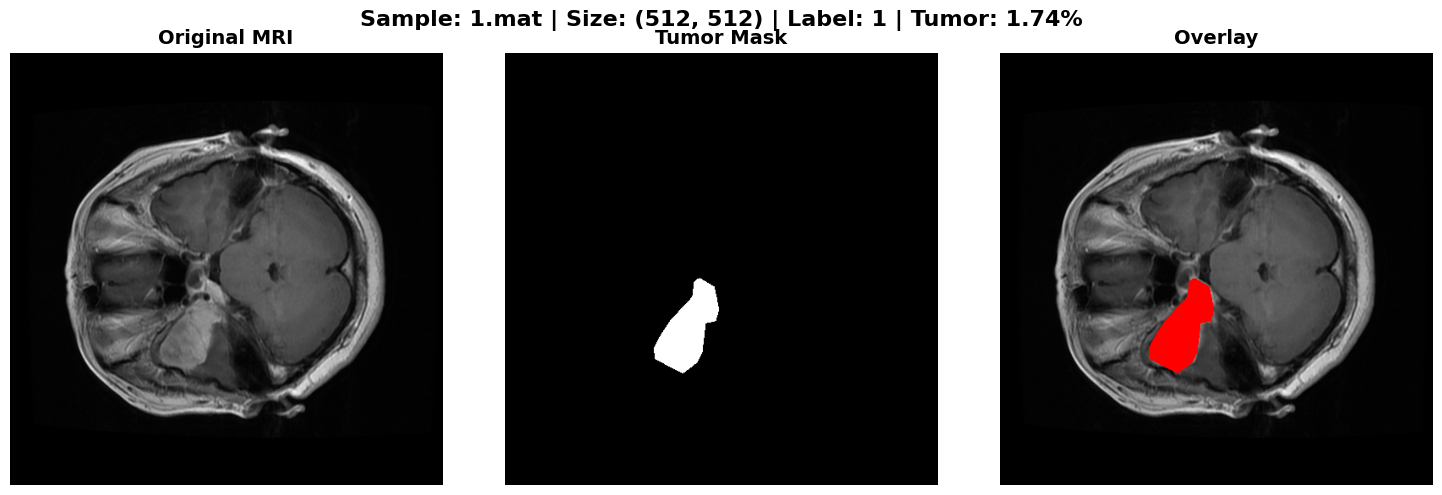


Sample: 1.mat
Shape: (512, 512)
Intensity range: [0.00, 3366.00]
Label: 1
Tumor coverage: 1.74%


In [52]:
# View specific sample - change this number
view_sample_number = 1

mat_file = os.path.join(data_dir, f'{view_sample_number}.mat')

with h5py.File(mat_file, 'r') as f:
    image = np.array(f['cjdata']['image']).astype(np.float32)
    mask = np.array(f['cjdata']['tumorMask']).astype(np.float32)
    label = np.array(f['cjdata']['label'])[0, 0]

# Normalize
image_norm = (image - image.min()) / (image.max() - image.min() + 1e-8)
tumor_percentage = (np.sum(mask > 0) / mask.size) * 100

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_norm, cmap='gray')
axes[0].set_title('Original MRI', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Tumor Mask', fontsize=14, fontweight='bold')
axes[1].axis('off')

overlay_rgb = np.stack([image_norm, image_norm, image_norm], axis=-1)
overlay_rgb[mask > 0] = [1, 0, 0]
axes[2].imshow(overlay_rgb)
axes[2].set_title('Overlay', fontsize=14, fontweight='bold')
axes[2].axis('off')

fig.suptitle(
    f'Sample: {view_sample_number}.mat | Size: {image.shape} | Label: {int(label)} | Tumor: {tumor_percentage:.2f}%',
    fontsize=16, fontweight='bold'
)
plt.tight_layout()
plt.show()

print(f"\nSample: {view_sample_number}.mat")
print(f"Shape: {image.shape}")
print(f"Intensity range: [{image.min():.2f}, {image.max():.2f}]")
print(f"Label: {int(label)}")
print(f"Tumor coverage: {tumor_percentage:.2f}%")

## 7. Save All Samples as PNG Files
This section saves all dataset samples (original MRI, tumor mask, and overlay) side by side as PNG files

In [57]:
# Configuration
output_folder = 'dataset_samples_png'  # Folder to save images
num_samples_to_save = 3064  # Number of samples to save (change to len(indices) for all)

# Create output directory
os.makedirs(output_folder, exist_ok=True)

print(f"Saving samples to: {os.path.abspath(output_folder)}")
print(f"Number of samples to save: {num_samples_to_save}")
print("="*80)

# Select samples to save
samples_to_save = indices[:num_samples_to_save]  # First N samples
# OR use random samples:
# samples_to_save = np.random.choice(indices, num_samples_to_save, replace=False)

# Save each sample
for idx, file_idx in enumerate(tqdm(samples_to_save, desc="Saving samples")):
    mat_file = os.path.join(data_dir, f'{file_idx}.mat')
    
    # Load data
    with h5py.File(mat_file, 'r') as f:
        image = np.array(f['cjdata']['image']).astype(np.float32)
        mask = np.array(f['cjdata']['tumorMask']).astype(np.float32)
        label = np.array(f['cjdata']['label'])[0, 0]
    
    # Normalize image
    image_norm = (image - image.min()) / (image.max() - image.min() + 1e-8)
    
    # Calculate tumor percentage
    tumor_percentage = (np.sum(mask > 0) / mask.size) * 100
    
    # Create overlay
    overlay_rgb = np.stack([image_norm, image_norm, image_norm], axis=-1)
    overlay_rgb[mask > 0] = [1, 0, 0]  # Red for tumor
    
    # Create figure with all three images side by side
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original MRI
    axes[0].imshow(image_norm, cmap='gray')
    axes[0].set_title('Original MRI Scan', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # Tumor Mask
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Tumor Segmentation Mask', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    # Overlay
    axes[2].imshow(overlay_rgb)
    axes[2].set_title('Overlay (Red = Tumor)', fontsize=14, fontweight='bold')
    axes[2].axis('off')
    
    # Add title with metadata
    fig.suptitle(
        f'Sample: {file_idx}.mat | Size: {image.shape} | Label: {int(label)} | Tumor Coverage: {tumor_percentage:.2f}%',
        fontsize=16, fontweight='bold'
    )
    
    # Save the figure
    output_filename = f'sample_{file_idx:04d}.png'
    output_path = os.path.join(output_folder, output_filename)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close()  # Close to free memory

print("\n" + "="*80)
print("DONE!")
print("="*80)
print(f"Total samples saved: {len(samples_to_save)}")
print(f"Output folder: {os.path.abspath(output_folder)}")
print(f"File naming format: sample_XXXX.png")
print("\nEach PNG file contains:")
print("  - Left: Original MRI scan")
print("  - Middle: Tumor segmentation mask")
print("  - Right: Overlay (red indicates tumor region)")
print("="*80)

Saving samples to: C:\Users\tahmi\Documents\FinalProject\dataset_samples_png
Number of samples to save: 3064


Saving samples: 100%|██████████████████████████████████████████████████████████████| 3064/3064 [26:22<00:00,  1.94it/s]


DONE!
Total samples saved: 3064
Output folder: C:\Users\tahmi\Documents\FinalProject\dataset_samples_png
File naming format: sample_XXXX.png

Each PNG file contains:
  - Left: Original MRI scan
  - Middle: Tumor segmentation mask
  - Right: Overlay (red indicates tumor region)


## 8. View Saved Samples
Display a few saved PNG files to verify

In [ ]:
from IPython.display import Image as IPImage, display

# Display first 3 saved images
saved_files = sorted([f for f in os.listdir(output_folder) if f.endswith('.png')])[:3]

print(f"Displaying {len(saved_files)} sample images from saved folder:\n")

for filename in saved_files:
    print(f"File: {filename}")
    display(IPImage(filename=os.path.join(output_folder, filename)))
    print("\n" + "-"*80 + "\n")